# Problem Set 0, Question 4: test the QED prediction

Use Finding Z to compare a photon-only $e^-e^+\to\mu^-\mu^+$ sample at $\sqrt{s}=29$ GeV with the angular prediction in Problem Set 0. Select **MadGraph only**, **MARK II-like 29 GeV $e^+e^-$ run**, the **QED only** model, and the **$e^+e^-\to\mu^+\mu^-$** process. Generate about 5,000 events or use the instructor-provided run.

The code assumes beam 1 is the incoming electron traveling along $+z$; check this convention in the run. Use a symmetric angular interval fully covered by the generation cuts. This simulated sample is not measured collision data.

Copy this notebook to your `work` directory, choose **Python (hep)**, and run it from the top. Enter the sample ID of your findingZ sample below.


## The experimental comparison

The upper panel is Figure 1(a) of M. E. Levi *et al.* (MARK II), [*Weak Neutral Currents in $e^+e^-$ Collisions at $\sqrt{s}=29$ GeV*](https://doi.org/10.1103/PhysRevLett.51.1941), Phys. Rev. Lett. **51** (1983) 1941–1944. This panel is reproduced from [SLAC-PUB-3177, PDF page 12](https://www.slac.stanford.edu/pubs/slacpubs/3000/slac-pub-3177.pdf#page=12).

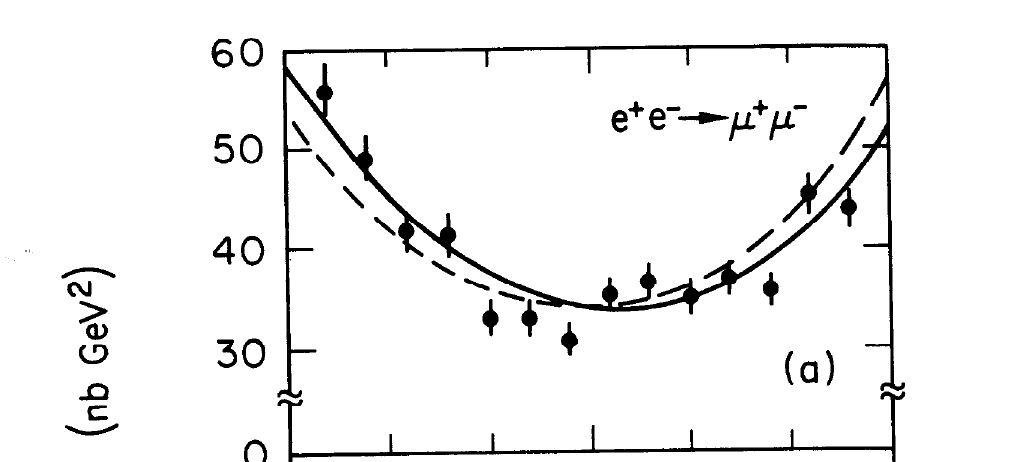
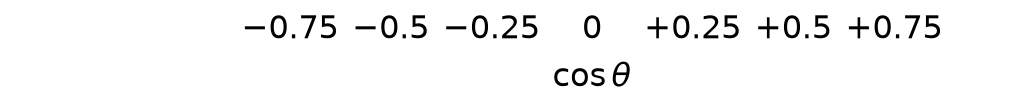

*Horizontal-axis labels added from the original shared axis; data and curves are unchanged.*

The horizontal coordinate is $\cos\theta$ (approximately $-0.75$ to $0.75$); the ordinate is $s\,d\sigma/d\cos\theta$ in $\mathrm{nb\,GeV^2}$. The image shows the measured points and the published curves. Use the **upper panel only** for Question 4. The dashed curve includes QED corrections through order $\alpha^3$; the solid curve also includes the fitted weak contribution.


## 1. Import the tools
NumPy handles arrays, pandas displays event tables, and Matplotlib draws plots.
FindingZ is used only to locate saved samples and read their event tables; the
angle, selection and histogram calculations below are explicit.
On CIT select **Python (hep)**; locally select **Python (Finding Z)**.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from findingz.catalog import load_catalog
from findingz.delphes import default_run_root
from findingz.hypotheses import build_sample_library
%matplotlib inline

## 2. Find your saved run
Run this cell, then copy the appropriate `sample_id` into the next cell.
The cross section shown here includes the **generation cuts**; it is not
necessarily the full-angle cross section.

In [10]:
library = build_sample_library(load_catalog(), default_run_root())
rows = []
for run_id, saved_sample in library.items():
    rows.append({"sample_id": run_id, "name": saved_sample.label,
                 "cross_section_pb": saved_sample.cross_section_pb,
                 "generated_events": saved_sample.generated_events})
display(pd.DataFrame(rows))

,sample_id,name,cross_section_pb,generated_events
0,run:finding-z-hep-58b4d92f86,testing-nocuts,70.320000,1000
1,run:finding-z-hep-a0480f4534,testingquestion,70.320000,1000
2,run:finding-z-hep-e52a32c665,qed-ee,29.140000,1000
3,run:finding-z-hep-cd8cfbb7ef,sm-ee,656.100000,1000
4,run:finding-z-hep-04036c9a86,test7,0.007953,1000
5,run:finding-z-hep-90457855f3,test5,656.100000,1000
6,run:finding-z-hep-d62b52eb81,test4,1322.000000,1000
7,run:finding-z-hep-c896066613,test1,1322.000000,1000


In [11]:
sample_id = ""  # Paste your sample_id from the table here.
assert sample_id in library, "Choose a sample_id from the table above, then rerun this cell."
sample = library[sample_id]
display(pd.Series(sample.config, name="Generation settings"))

name                                  finding-z-hep
events                                         1000
seed                                            225
collider_id                                markii29
collider                                         ee
model                                            sm
model_ufo_path                                 None
process                                 ee_mumu_qed
process_lines      [generate e- e+ > mu- mu+ / z h]
run_mode                                   madgraph
beam_energy_gev                                14.5
min_mass_gev                                   20.0
max_mass_gev                                   35.0
detector_id                                    none
detector_card                                  none
output_detail                              standard
collider_label         MARK II-like 29 GeV e+e- run
Name: Generation settings, dtype: object

## 3. Inspect the event table
Use the photon-only, MadGraph-only muon-pair sample at 29 GeV. Each row contains
one selected lepton pair. `l1` and `l2` label the two stored leptons, not their
charges. We must identify the negative muon explicitly.

`eta` is pseudorapidity; `pt` is transverse momentum in GeV. The rows have not yet
been subjected to our angular selection.

In [12]:
assert sample.config["collider"] == "ee"
assert sample.config["run_mode"] == "madgraph", "This exercise assumes a two-body parton-level sample."
frame = sample.load()
events = frame.loc[frame["channel"] == "mumu"].copy()
assert len(events) > 0, "The selected sample contains no muon pairs."
display(events[["l1_charge", "l1_pt", "l1_eta", "l2_charge", "l2_pt", "l2_eta"]].head())
print("Muon-pair events before analysis cuts:", len(events))

,l1_charge,l1_pt,l1_eta,l2_charge,l2_pt,l2_eta
0,-1,14.492802,-0.031517,1,14.492802,0.031517
1,-1,11.902539,0.649187,1,11.902539,-0.649187
2,-1,14.353127,-0.142937,1,14.353127,0.142937
3,-1,12.831499,-0.504594,1,12.831499,0.504594
4,-1,14.078435,0.244114,1,14.078435,-0.244114


Muon-pair events before analysis cuts: 1000


## 4. Calculate the scattering angle
For equal-energy incoming beams and this two-body sample, the laboratory frame
is the centre-of-mass frame. We measure the negative muon's angle from the incoming
electron, assumed to travel along $+z$ (beam 1 in `e- e+ > mu- mu+ / z h`).
Check that ordering in the displayed process definition.

Pseudorapidity is defined by $\eta=-\ln\tan(\theta/2)$, so
$\cos\theta=\tanh\eta$. No four-vector helper is needed here.
This shortcut does not perform a pair-rest-frame boost for radiative events.

In [13]:
assert ((events["l1_charge"] * events["l2_charge"]) < 0).all()
first_is_negative = events["l1_charge"] < 0
eta_minus = np.where(first_is_negative, events["l1_eta"], events["l2_eta"])
cos_theta = np.tanh(eta_minus)
events["cos_theta"] = cos_theta
display(events[["l1_charge", "l1_eta", "l2_eta", "cos_theta"]].head())

,l1_charge,l1_eta,l2_eta,cos_theta
0,-1,-0.031517,0.031517,-0.031506
1,-1,0.649187,-0.649187,0.571123
2,-1,-0.142937,0.142937,-0.141971
3,-1,-0.504594,0.504594,-0.465722
4,-1,0.244114,-0.244114,0.239378


## 5. Apply the angular selection
We compare absolute differential cross sections within $|\cos\theta|<0.7$. 

At 29 GeV, MadGraph's default $p_T>10$ GeV cut allows
$|\cos\theta|<0.724$, so it covers this narrower interval. The existing
20–35 GeV generation mass window also includes the two-body 29 GeV final state.
Check the saved run card if you use a different sample.

In [14]:
cos_acceptance = 0.7
selected = np.isfinite(events["cos_theta"]) & (events["cos_theta"].abs() < cos_acceptance)
selected_events = events.loc[selected].copy()
assert len(selected_events) > 0, "No events pass this selection."
print(f"Selected {len(selected_events)} of {len(events)} muon-pair events")

Selected 952 of 1000 muon-pair events


## 6. Count events in angular bins
Each unweighted leading-order event counts once. Check that the stored event
weights are equal, then count the selected events in each bin. We do **not**
normalize the histogram to one.

In [18]:
if "weight" in frame:
    event_weights = frame["weight"].to_numpy()
    assert np.isfinite(event_weights).all() and (event_weights > 0).all()
    assert np.allclose(event_weights, event_weights[0]), "Unequal weights require a weighted analysis."

number_of_bins = 16
bin_edges = np.linspace(-cos_acceptance, cos_acceptance, number_of_bins + 1)
counts, _ = np.histogram(selected_events["cos_theta"], bins=bin_edges)
bin_widths = np.diff(bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
display(pd.DataFrame({"lower_edge": bin_edges[:-1], "upper_edge": bin_edges[1:],
                      "count": counts}))

,lower_edge,upper_edge,count
0,-0.7000,-0.6125,80
1,-0.6125,-0.5250,64
2,-0.5250,-0.4375,60
3,-0.4375,-0.3500,60
4,-0.3500,-0.2625,56
5,-0.2625,-0.1750,69
6,-0.1750,-0.0875,56
7,-0.0875,0.0000,49
8,0.0000,0.0875,50
9,0.0875,0.1750,50


### Convert counts to an absolute cross section
The saved MadGraph cross section refers to **all generated events**, including
those rejected by our analysis cut. Each generated event represents
$\sigma_{\rm MG}/N_{\rm generated}$; do not divide by the number selected.
Convert pb to nb, divide each bin's cross section by its width, then multiply by
$s=(2E_{\rm beam})^2$ to match the experimental figure. No luminosity is needed.

In [19]:
assert sample.cross_section_pb is not None and sample.cross_section_pb > 0
assert sample.generated_events is not None and sample.generated_events > 0
assert len(frame) <= sample.generated_events, "This exercise requires at most one pair per generated event."
sigma_mg_pb = sample.cross_section_pb
n_generated = sample.generated_events
sqrt_s_gev = 2 * sample.config["beam_energy_gev"]
s_gev2 = sqrt_s_gev**2

event_cross_section_nb = (sigma_mg_pb / 1000) / n_generated
dsigma_dcos_nb = counts * event_cross_section_nb / bin_widths
simulation_s_dsigma = s_gev2 * dsigma_dcos_nb

print(f"MadGraph cross section with generation cuts: {sigma_mg_pb:.2f} pb")
print(f"After our angular cut: {counts.sum() * event_cross_section_nb * 1000:.2f} pb")
display(pd.DataFrame({"cos_theta": bin_centers, "count": counts,
                      "s_dsigma_dcos_nb_GeV2": simulation_s_dsigma}))

MadGraph cross section with generation cuts: 70.32 pb
After our angular cut: 66.94 pb


,cos_theta,count,s_dsigma_dcos_nb_GeV2
0,-0.65625,80,54.070053
1,-0.56875,64,43.256042
2,-0.48125,60,40.552539
3,-0.39375,60,40.552539
4,-0.30625,56,37.849037
5,-0.21875,69,46.635420
6,-0.13125,56,37.849037
7,-0.04375,49,33.117907
8,0.04375,50,33.793783
9,0.13125,50,33.793783


## 7. Calculate the absolute QED prediction
For massless muons at tree level, with $x=\cos\theta$,
$$s\frac{d\sigma}{dx}=\frac{\pi\alpha^2}{2}(1+x^2).$$
In natural units, $1\ \mathrm{GeV}^{-2}=389379.37\ \mathrm{nb}$.
Use this conversion for both the analytical total cross section and the plotted
quantity. Integrate $1+x^2$ over each bin and divide by the bin width, so the
prediction is a **bin-averaged differential cross section**.

Start with $\alpha^{-1}=137.036$ for the analytical calculation. The existing
MadGraph sample uses $132.507$; try that value below to isolate the effect of the
coupling choice. Neither prediction is rescaled to fit the other.

In [20]:
alpha_inverse = 137.036  # Try 132.507 to match the standard MadGraph parameter card.
alpha = 1 / alpha_inverse
gev_minus2_to_nb = 389379.37

sigma_qed_total_nb = 4 * np.pi * alpha**2 / (3 * s_gev2) * gev_minus2_to_nb
print(f"Analytical full-angle cross section: {sigma_qed_total_nb * 1000:.2f} pb")

lower = bin_edges[:-1]
upper = bin_edges[1:]
bin_integrals = (upper + upper**3 / 3) - (lower + lower**3 / 3)
qed_s_dsigma = (np.pi * alpha**2 / 2) * gev_minus2_to_nb * bin_integrals / bin_widths
sigma_qed_selected_nb = np.sum(qed_s_dsigma * bin_widths) / s_gev2
print(f"Analytical cross section within the angular cut: {sigma_qed_selected_nb * 1000:.2f} pb")

Analytical full-angle cross section: 103.28 pb
Analytical cross section within the angular cut: 63.08 pb


## 8. Plot on the experimental figure's absolute scale
The points show $s\,d\sigma/d\cos\theta$ in $\mathrm{nb\,GeV^2}$, not event
fractions. The error bars use the simple $\sqrt{n_i}$ approximation for finite
Monte Carlo counting uncertainty and the same conversion as the bin values.
They omit MadGraph's integration uncertainty and physical systematic uncertainties;
they are not experimental uncertainties. Empty/sparse bins need more careful
intervals, and fixed-size simulation bin counts are correlated.

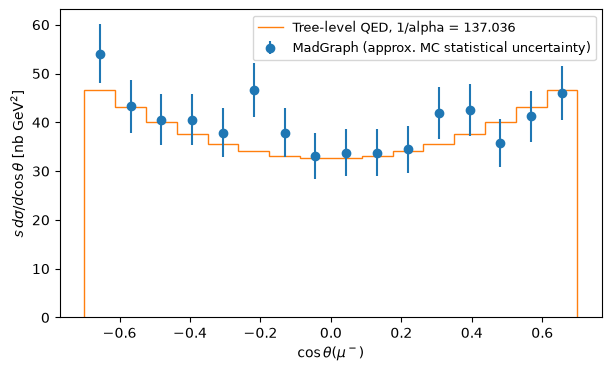

In [21]:
simulation_error = np.sqrt(counts) * event_cross_section_nb / bin_widths * s_gev2
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(bin_centers, simulation_s_dsigma, yerr=simulation_error,
            fmt="o", label="MadGraph (approx. MC statistical uncertainty)")
ax.stairs(qed_s_dsigma, bin_edges, label=f"Tree-level QED, 1/alpha = {alpha_inverse:g}")
ax.set_xlabel(r"$\cos\theta$")
ax.set_ylabel(r"$s\,d\sigma/d\cos\theta$ [nb GeV$^2$]")
ax.legend(fontsize=9)
plt.show()

### Discuss the differences
The full-angle analytical total is not directly comparable with MadGraph's
generation-cut cross section. Compare quantities over the **same angular range**
and check the coupling (`aEWM1`) and cuts (`ptl`, `etal`) in the saved cards.
Our selected interval must be fully covered by the generated sample: this
normalization cannot recover events excluded during generation.

The published curves include radiative corrections and, for the solid curve,
a weak contribution absent from this tree-level photon-only simulation.
Changing $\alpha$ can explain a normalization shift but does not reproduce all
those corrections. The experimental error bars and our simulation error bars
also represent different sources of uncertainty.

## Written answers

In this notebook, answer all parts of Problem Set 0, Question 4. Include your 29 GeV total cross section and the curve for $s\,d\sigma/d\cos\theta$, then compare it with Figure 1(a) of the MARK II reference. Record the Finding Z run ID, beam energy, event count, generation cuts, and any angular restriction. Compare the simulated **absolute differential cross section** with the bin-averaged QED prediction, allowing for finite-event fluctuations. Explain how the idealized simulation differs from the measurement.

Use the saved cross section and total generated event count for normalization. State the coupling and angular acceptance used in each comparison.
